# 🧪 Image Segmentation Lab

## 1. Otsu Thresholding

In this lab, you will apply **Otsu’s method** for automatic thresholding to a set of grayscale images.
You will display the original image, the segmented result, and the histogram with the threshold marked.


Processing: head.png


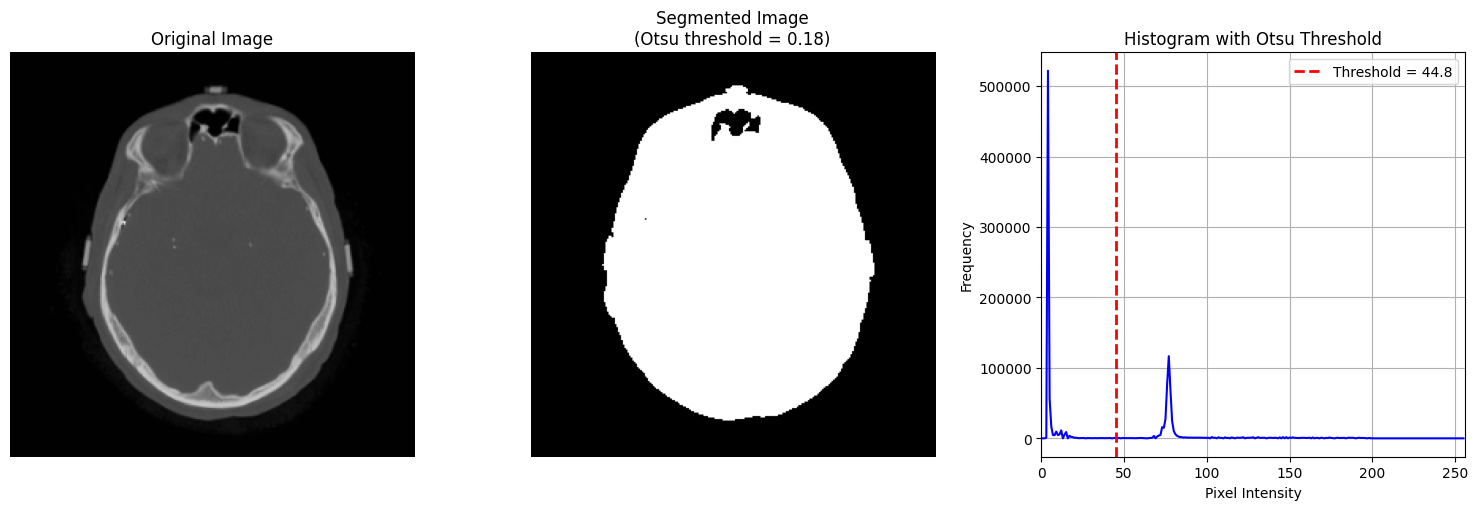


Processing: pencils.png


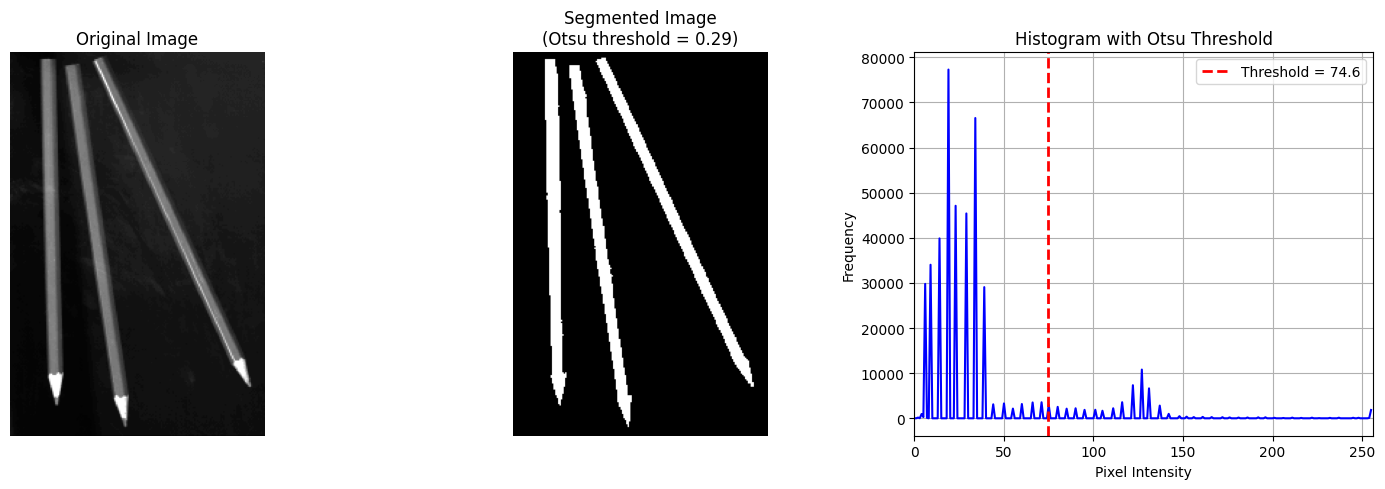


Processing: sonnet.png


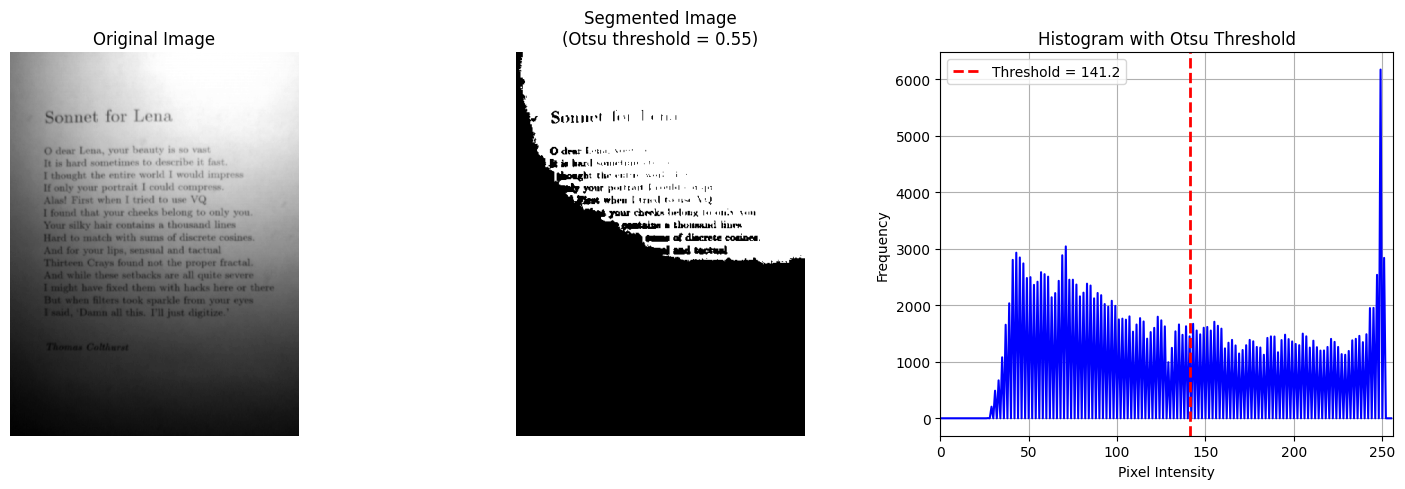


Processing: square.png


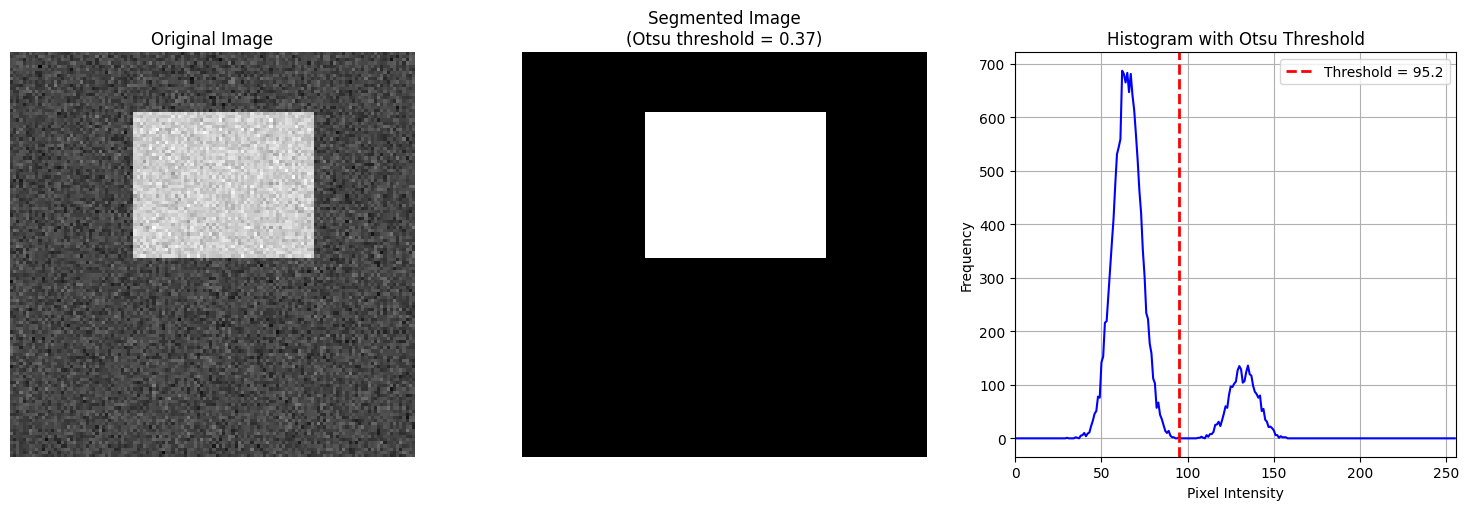


Processing: star.png


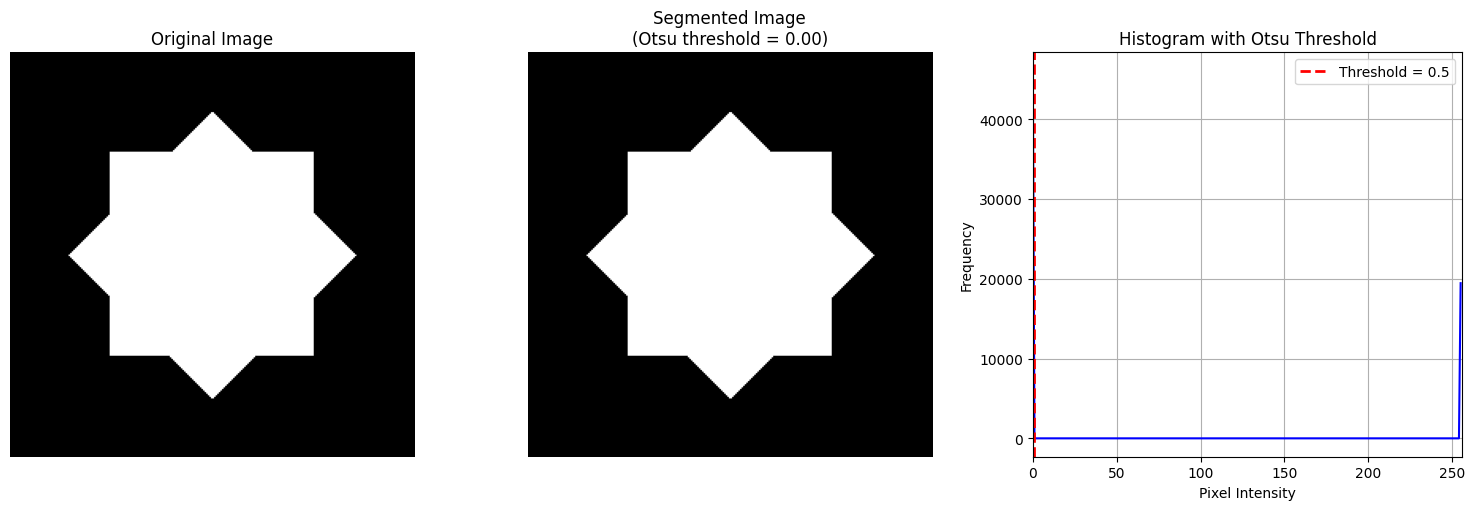


Processing: star2.png


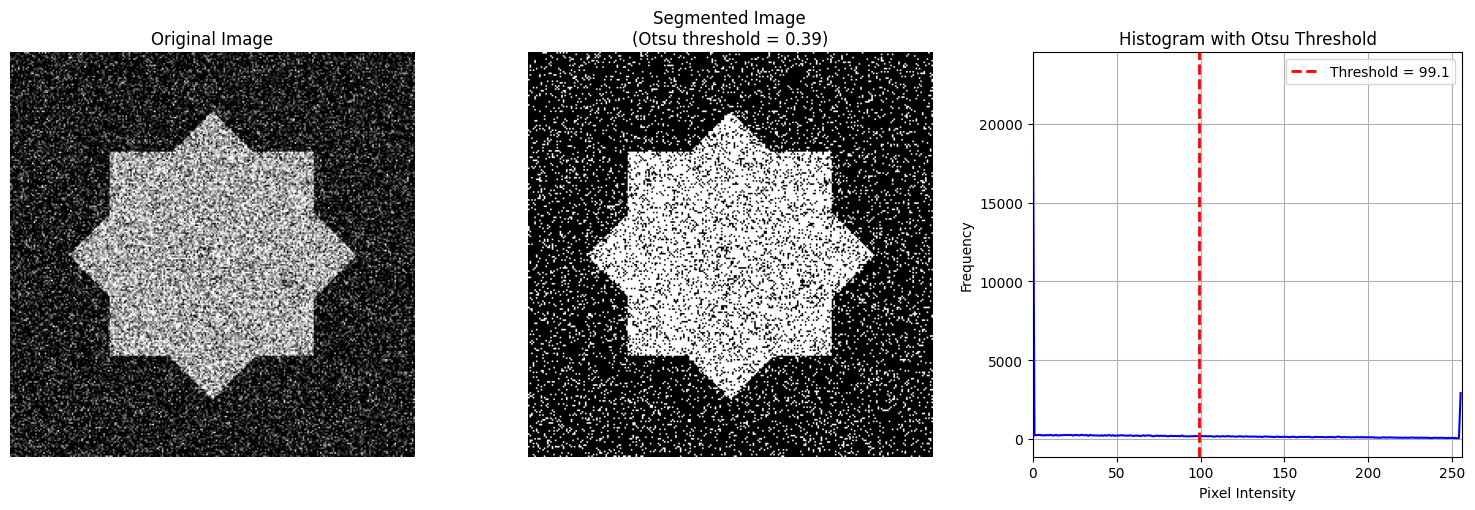

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.filters import threshold_otsu
from pathlib import Path
import cv2

def otsu_threshold(image_path):
    # Load image in grayscale
    img = imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    # Compute histogram (OpenCV)
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])

    # Normalize image to [0, 1] for threshold_otsu (expects float)
    img_norm = img.astype("float32") / 255.0
    thresh = threshold_otsu(img_norm)

    # Binarize image using threshold
    binary_img = img_norm > thresh

    # Plot everything
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    axs[0].imshow(img, cmap='gray')
    axs[0].set_title("Original Image")
    axs[0].axis("off")

    axs[1].imshow(binary_img, cmap='gray')
    axs[1].set_title(f"Segmented Image\n(Otsu threshold = {thresh:.2f})")
    axs[1].axis("off")

    axs[2].plot(hist, color='blue')
    axs[2].axvline(thresh * 255, color='red', linestyle='--', linewidth=2,
                   label=f'Threshold = {thresh * 255:.1f}')
    axs[2].set_title("Histogram with Otsu Threshold")
    axs[2].set_xlim([0, 256])
    axs[2].set_xlabel("Pixel Intensity")
    axs[2].set_ylabel("Frequency")
    axs[2].legend()
    axs[2].grid(True)

    plt.tight_layout()
    plt.show()

# Modify this path to point to your 'imgs' folder
images_folder = Path("../imgs")
image_files = sorted(images_folder.glob("*.png"))  # Adjust extension if necessary

for img_path in image_files:
    print(f"\nProcessing: {img_path.name}")
    otsu_threshold(img_path)


### ✍️ Exercise

For each image:

- Was the segmentation successful?
- Did the threshold clearly separate foreground and background?
- What limitations did you notice?

Write your answers below each output.
